In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

TODO:
1) X - Save Models
2) X train from script
3) X Subset fragment lengths
4) X explore variance of counts
5) Add jitter
6) add count head
7) X Don't filter out duplicates in frag h5 creation
8) X Only fit forward starts and reverse ends

In [2]:
import os

import pandas as pd
import pysam

from tqdm.notebook import tqdm
tqdm.pandas()

from fragmentomics_tools.dataframe import RegionDataFrame, SampleAndRegionDataFrame
from lib import load_ibd_sample_df, build_marker_gene_rdf

In [3]:
sdf = load_ibd_sample_df().query("DIAGNOSIS == 'Ulcerative Colitis'")

In [4]:
from data import HematopoieticGeneExpression
hge = HematopoieticGeneExpression.load().expand_regions(2048, 2048).attach_blacklist_regions("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz").rename(columns={'index': 'gene_name'})

In [5]:
marker_genes = build_marker_gene_rdf(hge)

In [6]:
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(marker_genes, sdf).attach_fragment_arrays(num_cores=24)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61957/61957 [3:00:24<00:00,  5.72it/s]


In [ ]:
pd.DataFrame(srdf).query("direction == 'up_in_colon' and label == 4")

In [15]:
def make_counts(record): # 
    fa = record['fragment_array'].drop_duplicate_fragments().subset_fragment_lengths(40, 60).mask_overlapping_fragments(record.blacklist_regions, expansion=120)
    return pd.Series(dict(sample_id=record.sample_id, gene_name=record.gene_name, blood_expression=record.expression, fc=record.avg_log2FC, label=record.label, fwd=fa.subset_by_fragment_strand("+").first_covered_base_counts.sum(), bkwd=fa.subset_by_fragment_strand("-").last_covered_base_counts.sum()))
raw_counts = pd.DataFrame(srdf).progress_apply(make_counts, axis=1)

  0%|          | 0/113155 [00:00<?, ?it/s]

In [34]:
counts = raw_counts.query("fwd + bkwd > 100 and fwd > 20 and bkwd > 20").copy()
counts.loc[:, 'ratio'] = counts.bkwd/(counts.fwd + counts.bkwd + 1)

,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,up_ratio,down_ratio
sample_id,,,,,,,,
RD-36063,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8,0.445591,0.488889
RD-36064,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_4,0.457840,0.492857
RD-36067,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_7,0.497405,0.542125
RD-36069,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_19,0.469790,0.511050
RD-36070,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_13,0.459643,0.425676
...,...,...,...,...,...,...,...,...
RD-56172,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 4,Site_13,0.480087,0.494186
RD-50563,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 6,Site_13,0.459825,0.490196
RD-50565,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 1,Site_13,0.463975,0.524324


In [83]:
up_mean_ratios = counts.query("fc > 8")[['gene_name', 'sample_id', 'ratio']].set_index(['sample_id', 'gene_name'])[['ratio']].unstack(level=0).dropna().mean()
up_mean_ratios.index = up_mean_ratios.index.droplevel()

down_mean_ratios = counts.query("fc < -7")[['gene_name', 'sample_id', 'ratio']].set_index(['sample_id', 'gene_name'])[['ratio']].unstack(level=0).dropna().mean()
down_mean_ratios.index = down_mean_ratios.index.droplevel()

ratios = pd.DataFrame(up_mean_ratios.rename('up_ratio')).join(down_mean_ratios.rename('down_ratio'), how='inner')
df = pd.DataFrame(sdf).set_index("sample_id").join(ratios, how='inner')
df['ratio'] = df.up_ratio - df.down_ratio

In [84]:
df

,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,up_ratio,down_ratio,ratio
sample_id,,,,,,,,,
RD-36063,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8,0.445591,0.488889,-0.043298
RD-36064,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_4,0.457840,0.492857,-0.035017
RD-36067,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_7,0.497405,0.542125,-0.044720
RD-36069,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_19,0.469790,0.511050,-0.041260
RD-36070,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_13,0.459643,0.425676,0.033967
...,...,...,...,...,...,...,...,...,...
RD-56172,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 4,Site_13,0.480087,0.494186,-0.014099
RD-50563,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 6,Site_13,0.459825,0.490196,-0.030371
RD-50565,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 1,Site_13,0.463975,0.524324,-0.060349


WARNING	2024-04-08 09:15:04,027	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):

WARNING	2024-04-08 09:15:04,028	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):

WARNING	2024-04-08 09:15:04,028	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):



<Axes: xlabel='label', ylabel='ratio'>

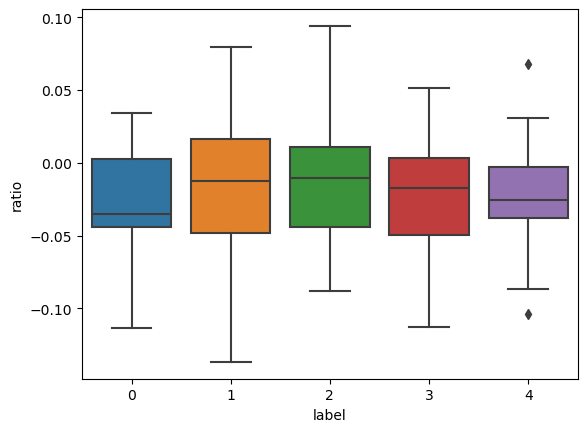

In [88]:
import seaborn
seaborn.boxplot(df[['label', 'ratio']], x='label', y='ratio')

In [89]:
df

,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,up_ratio,down_ratio,ratio
sample_id,,,,,,,,,
RD-36063,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8,0.445591,0.488889,-0.043298
RD-36064,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_4,0.457840,0.492857,-0.035017
RD-36067,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_7,0.497405,0.542125,-0.044720
RD-36069,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_19,0.469790,0.511050,-0.041260
RD-36070,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_13,0.459643,0.425676,0.033967
...,...,...,...,...,...,...,...,...,...
RD-56172,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Severe,Patient Group 4,Site_13,0.480087,0.494186,-0.014099
RD-50563,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 6,Site_13,0.459825,0.490196,-0.030371
RD-50565,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 1,Site_13,0.463975,0.524324,-0.060349


In [92]:
import numpy as np
np.corrcoef(df[['up_ratio', 'down_ratio']].T)

array([[ 1.        , -0.01055648],
       [-0.01055648,  1.        ]])

<Axes: xlabel='up_ratio', ylabel='down_ratio'>

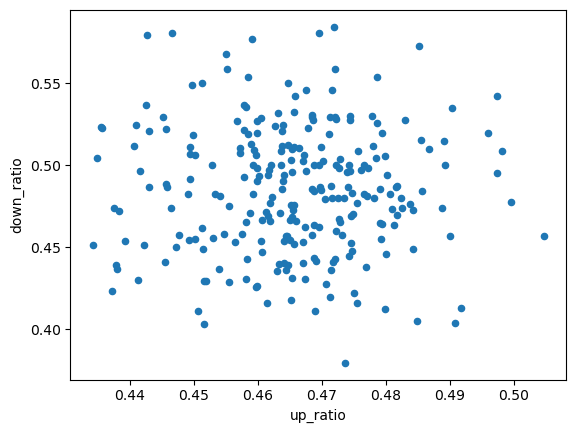

In [91]:
df.plot.scatter(x='up_ratio', y='down_ratio')

In [165]:
bad_genes = ["TMSB15B", "MATR3", "MATR3"]
X = counts[['gene_name', 'sample_id', 'ratio']].query("gene_name not in @bad_genes").set_index(['sample_id', 'gene_name']).unstack(level=0).dropna().T # .pivot(index='sample_id', columns='gene_name', values='ratio')
y = counts[['sample_id', 'label']].drop_duplicates().set_index('sample_id')
X.index = X.index.droplevel()
X = X.sort_index()
y = y.sort_index()
assert (X.index == y.index).all()

In [166]:
y[y == 1] = 0
y[y == 2] = 0
y[y == 3] = 1
y[y == 4] = 1

In [167]:
y.value_counts()

label
0        208
1         97
Name: count, dtype: int64

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2)
reg = LogisticRegression(random_state=0, class_weight='balanced')
res = cross_val_score(reg, X, y.values.ravel(), cv=10)
#reg.fit(X_train, y_train)
#obs = y_test.values.squeeze().squeeze().tolist()
#pred = reg.predict(X_test).squeeze().tolist()

ValueError: Found input variables with inconsistent numbers of samples: [28, 305]

In [171]:
res

array([0.35483871, 0.35483871, 0.41935484, 0.38709677, 0.5483871 ,
       0.6       , 0.36666667, 0.5       , 0.36666667, 0.7       ])

In [170]:
from sklearn.metrics import balanced_accuracy_score
roc_auc_score(res, y.values)

ValueError: continuous format is not supported

In [161]:
pd.DataFrame(dict(pred=res, obs=y.values.ravel())).sort_values('pred').value_counts()

pred  obs
1     0      111
0     0       97
      1       54
1     1       43
Name: count, dtype: int64

In [191]:
list(zip(obs, pred))

[(1, 1.3642218664619004),
 (2, 2.732376837981592),
 (4, 2.852963301030906),
 (2, 1.9505798616451584),
 (1, 2.5179501510554196)]

In [190]:
roc_auc_score(obs, pred, multi_class='ovr')

AxisError: axis 1 is out of bounds for array of dimension 1

ratio    Axes(0.125,0.11;0.775x0.77)
dtype: object

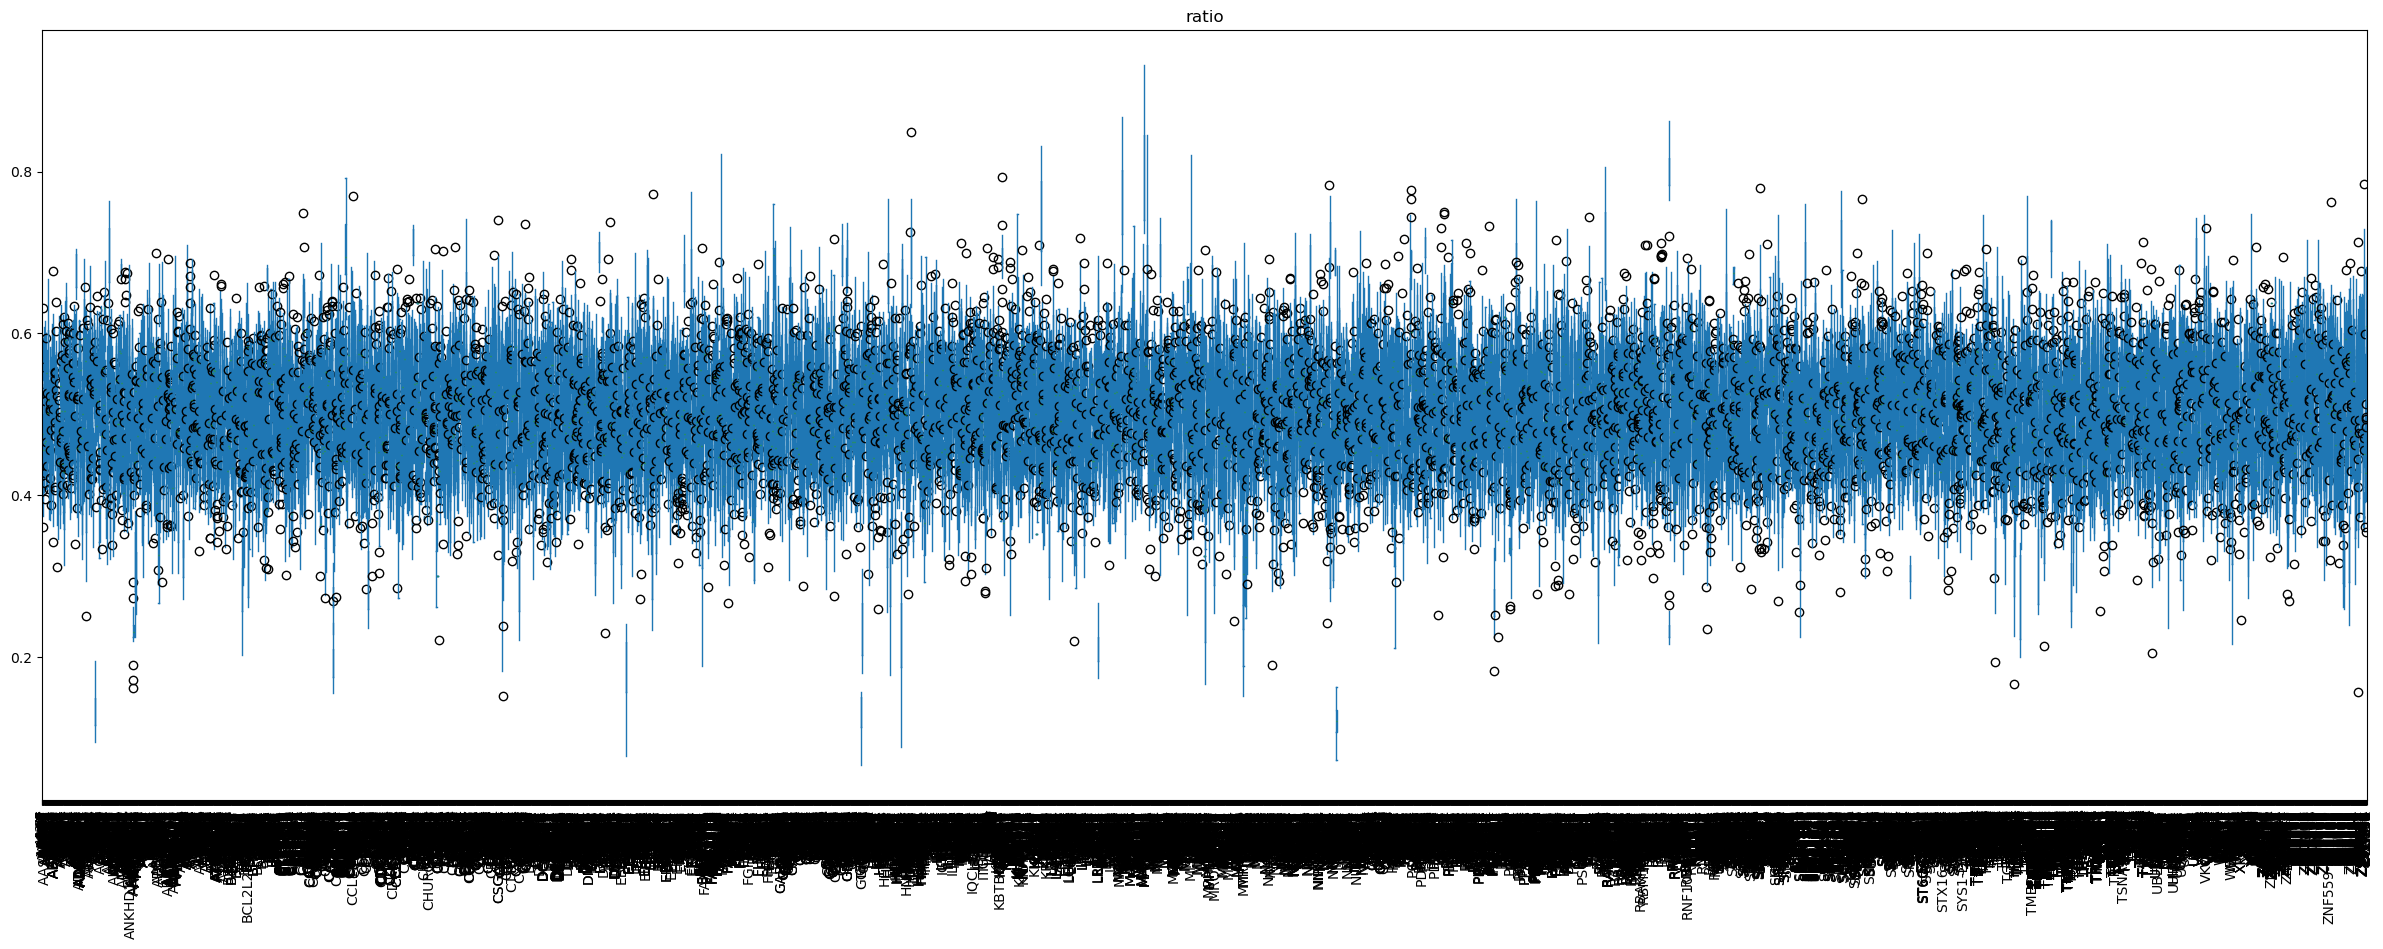

In [244]:
counts[['ratio', 'gene_name']].plot.box(by='gene_name', rot=90, figsize=(30, 10))

In [335]:
import glob
sample_ids = [x.split("/")[-1].split(".")[2] for x in glob.glob("/scratch/karius/bias_correction_model/merged.negative_binomial.RD-*.2.res")]
sample_ids

['RD-56154',
 'RD-56155',
 'RD-56153',
 'RD-56165',
 'RD-56169',
 'RD-56150',
 'RD-56168',
 'RD-56170',
 'RD-56167',
 'RD-56166']

In [336]:
load_ibd_sample_df().query("sample_id in @sample_ids")

,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER
89,RD-56170,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 2,Site_13
88,RD-56169,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 6,Site_13
87,RD-56168,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13
86,RD-56167,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 1,Site_13
84,RD-56165,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13
85,RD-56166,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13
0,RD-56150,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 1,Site_13
1,RD-56153,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 2,Site_13
2,RD-56154,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 4,Site_13
3,RD-56155,2,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Mild,Patient Group 3,Site_13


In [207]:
val_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(val_rdf, load_ibd_sample_df().query("sample_id in @sample_ids"))

In [208]:
test_srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(test_rdf, load_ibd_sample_df().query("sample_id in @sample_ids"))

In [302]:
%%time
dfs = []
for i, sample_id in enumerate(sample_ids):
    print(i, len(sample_ids))
    model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/merged.negative_binomial.{sample_id}.2.res').cpu()
    pred = model.predict_from_rdf(val_rdf)
    fwd_pred = pred.fwd_start_counts_dist.progress_apply(lambda x: x.mean().sum()).rename("fwd_pred")
    rev_pred = pred.bkwd_stop_counts_dist.progress_apply(lambda x: x.mean().sum()).rename("rev_pred")
    pred_ratio = pd.DataFrame((rev_pred/(fwd_pred + rev_pred)).rename('pred_ratio'))
    pred_ratio['sample_id'] = sample_id
    pred_ratio = pd.DataFrame(test_rdf)[['gene_name']].join(pred_ratio)
    dfs.append(pred_ratio)

0 9


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 879.26it/s]


1 9


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 882.88it/s]


2 9


...

7 9


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 842.47it/s]


8 9


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 757.52it/s]

CPU times: user 4min 27s, sys: 2.84 s, total: 4min 30s
Wall time: 1min 33s


In [305]:
pred_df = pd.concat(dfs)

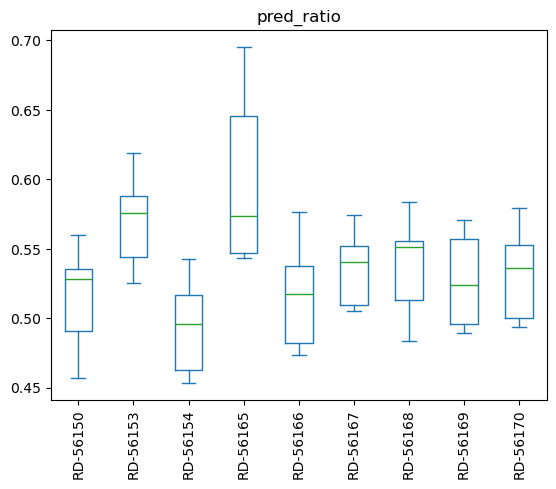

In [306]:
_ = pred_df.plot.box(by="sample_id", rot=90)

In [317]:
sdf.query("sample_id == @sample_id"), sample_id

(Empty SampleDataFrame
 Columns: [sample_id, label, frag_h5, DIAGNOSIS, ENDO_CATEGORY, Cluster, SITE_NUMBER]
 Index: [],
 'RD-56154')

In [ ]:
%%time
all_stats = {}
# res = {}
for i, sample_id in enumerate(sample_ids):
    print(i+1, len(sample_ids), sample_id)
    model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/merged.negative_binomial.merged.2.res').cpu()
    tmp = model.predict_from_rdf_and_sdf(val_rdf.attach_blacklist_regions("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz"), load_ibd_sample_df().query("sample_id == @sample_id"))
    stats = tmp.build_stats_df()
    all_stats[sample_id] = stats
    # res[sample_id] = (stats.bkwd_stop_counts_count/(stats.bkwd_stop_counts_count + stats.fwd_start_counts_count))SipsTea/comments/1bwf0x4/that_random_gym_fat_dude_is_always_surprisingly/

1 10 RD-56154
Predicting dists (1/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 914.67it/s]

Building fragment arrays (2/5)



100%|███████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 78.04it/s]


Merging fragment arrays (3/5)


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1310.61it/s]


Building observed arrays (4/5)
Building observed arrays (4/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 686.72it/s]


Merging Results (5/5)


  7%|██████▋                                                                                         | 14/200 [00:04<00:58,  3.17it/s]

In [ ]:
all_dfs = []
for key, sub_df in all_stats.items():
    sub_df['sample_id'] = key
    all_dfs.append(sub_df)
stats_merged_df = pd.concat(all_dfs).set_index("sample_id")
stats_merged_df = stats_merged_df.query("fwd_start_counts_count > 50")

In [ ]:
stats_merged_df.head()

In [ ]:
(stats_merged_df.bkwd_stop_counts_pred_count/(stats_merged_df.bkwd_stop_counts_pred_count + stats_merged_df.fwd_start_counts_pred_count)).reset_index().plot.box(by='sample_id', rot=90)

In [ ]:
(stats_merged_df.bkwd_stop_counts_count/(stats_merged_df.bkwd_stop_counts_count + stats_merged_df.fwd_start_counts_count)).reset_index().plot.box(by='sample_id', rot=90)

In [ ]:
bkwd_cnts = stats_merged_df.bkwd_stop_counts_count/stats_merged_df.bkwd_stop_counts_pred_count
fwd_cnts = stats_merged_df.fwd_start_counts_count/stats_merged_df.fwd_start_counts_pred_count
(bkwd_cnts/(bkwd_cnts + fwd_cnts)).reset_index().plot.box(by='sample_id', rot=90)

sample_id
RD-56169    200
Name: count, dtype: int64


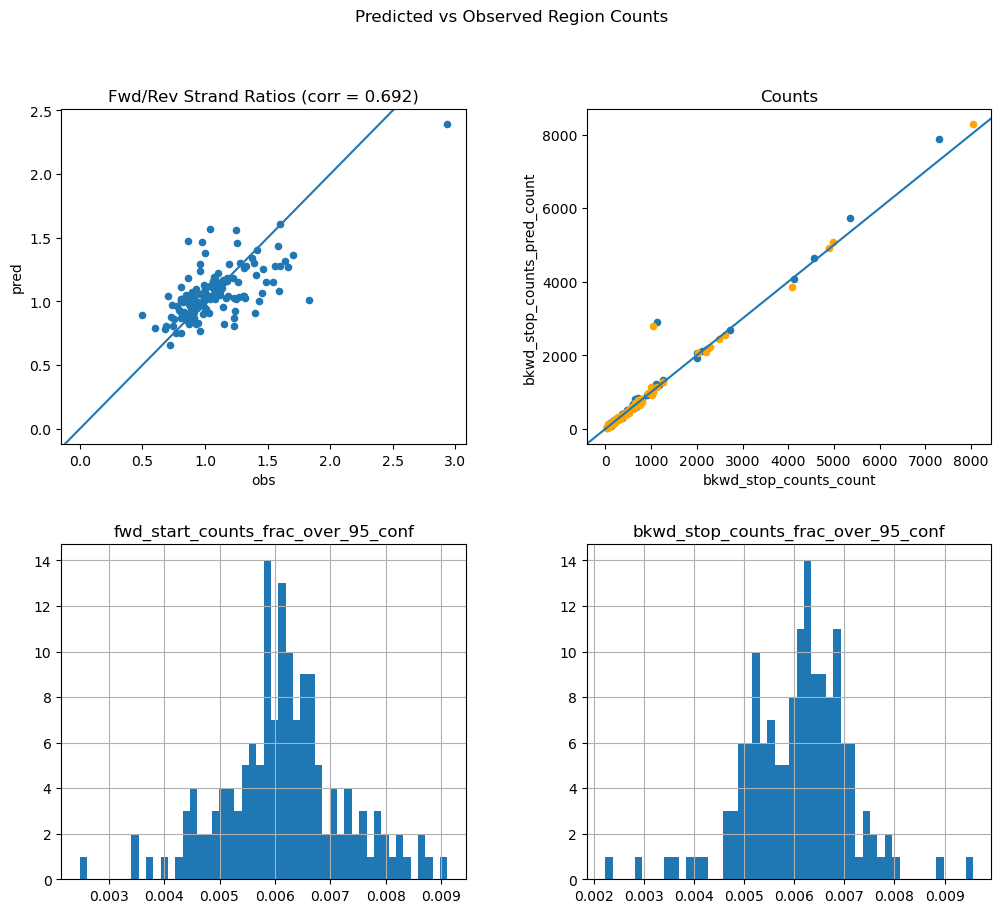

In [343]:
def plot(index):
    print(all_dfs[index].sample_id.value_counts())
    all_dfs[index].query("fwd_start_counts_count > 50").dropna().make_qc_plots()

plot(3)

In [185]:
ratios_df = pd.DataFrame(test_srdf).join(obs_ratio).set_index(["gene_name", "sample_id"]).join(pred_df.set_index(['gene_name', 'sample_id']))[['label', 'direction', 'avg_log2FC', 'obs_ratio', 'pred_ratio']]

NameError: name 'obs_ratio' is not defined

In [ ]:
ratios_df

In [ ]:
ratios_df[['obs_ratio']].groupby('gene_name').mean().sort_values(by='obs_ratio').tail(5) # 'pred_ratio'

In [ ]:
tmp = ratios_df.groupby(['label', 'sample_id', 'direction']).median()
tmp.pred_ratio.sort_values().reset_index()[['direction', 'label', 'pred_ratio']].boxplot(by=['direction', 'label'], rot=90, figsize=(10, 4))

In [ ]:
pd.DataFrame(srdf)[['gene_name', 'label']].join(obs_ratio).head(18).sort_values('label')

In [9]:
from lib import load_ibd_sample_df
sdf = load_ibd_sample_df() # .query("sample_id == 'RD-56170'")

In [20]:
from ibd.data import HematopoieticGeneExpression
hge_raw = HematopoieticGeneExpression.load().expand_regions(2048, 2048).attach_blacklist_regions("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz")

In [ ]:
def plot_real_params():
    sample_id = sample_ids[0]
    model = BackgroundModelModule.load('/scratch/karius/bias_correction_model/merged.negative_binomial.RD-56170.1.res').cpu()
    val_dataset = FragmentEndpointsDataset(val_rdf, sdf.query("sample_id == @sample_id"), model)
    pd.DataFrame(model.model(val_dataset[0][0].cpu()).cpu().detach()).T.hist(sharex=True)

In [ ]:
plot_real_params()

In [167]:
sample_id = "RD-56169"
# sample_id = "merged"
# /scratch/karius/bias_correction_model/merged.negative_binomial.base_model.3.res
# model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/{sample_id}.two_residual.negative_binomial.2.res').cpu()
model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/merged.negative_binomial.{sample_id}.2.res').cpu()

In [197]:
hge_raw.query("gene_name == 'TYK2'")

,gene_name,gene_id,contig,strand,start,stop,expression,blacklist_regions
15888,TYK2,ENSG00000105397,chr19,-,10348481,10368628,43.462897,"[chr19:10349386-10349417, chr19:10352697-10352..."


In [198]:
res = model.predict_from_rdf_and_sdf(hge_raw.query("gene_name == 'TYK2'"), (sdf if sample_id == 'merged' else sdf.query("sample_id == @sample_id")))

Predicting dists (1/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 652.40it/s]


Building fragment arrays (2/5)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.19s/it]


Merging fragment arrays (3/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 548.63it/s]


Building observed arrays (4/5)
Building observed arrays (4/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 415.98it/s]

Merging Results (5/5)


(<Figure size 2500x1800 with 9 Axes>,
 [<Axes: >,
  <Axes: title={'center': 'fwd_start_counts'}>,
  <Axes: title={'center': 'smoothed_ratio'}>,
  <Axes: title={'center': 'log10(1+count)'}>,
  <Axes: title={'center': 'bkwd_stop_counts'}>,
  <Axes: title={'center': 'smoothed_ratio'}>,
  <Axes: title={'center': 'log10(1+count)'}>,
  <Axes: >,
  <Axes: xlabel='chr19'>])

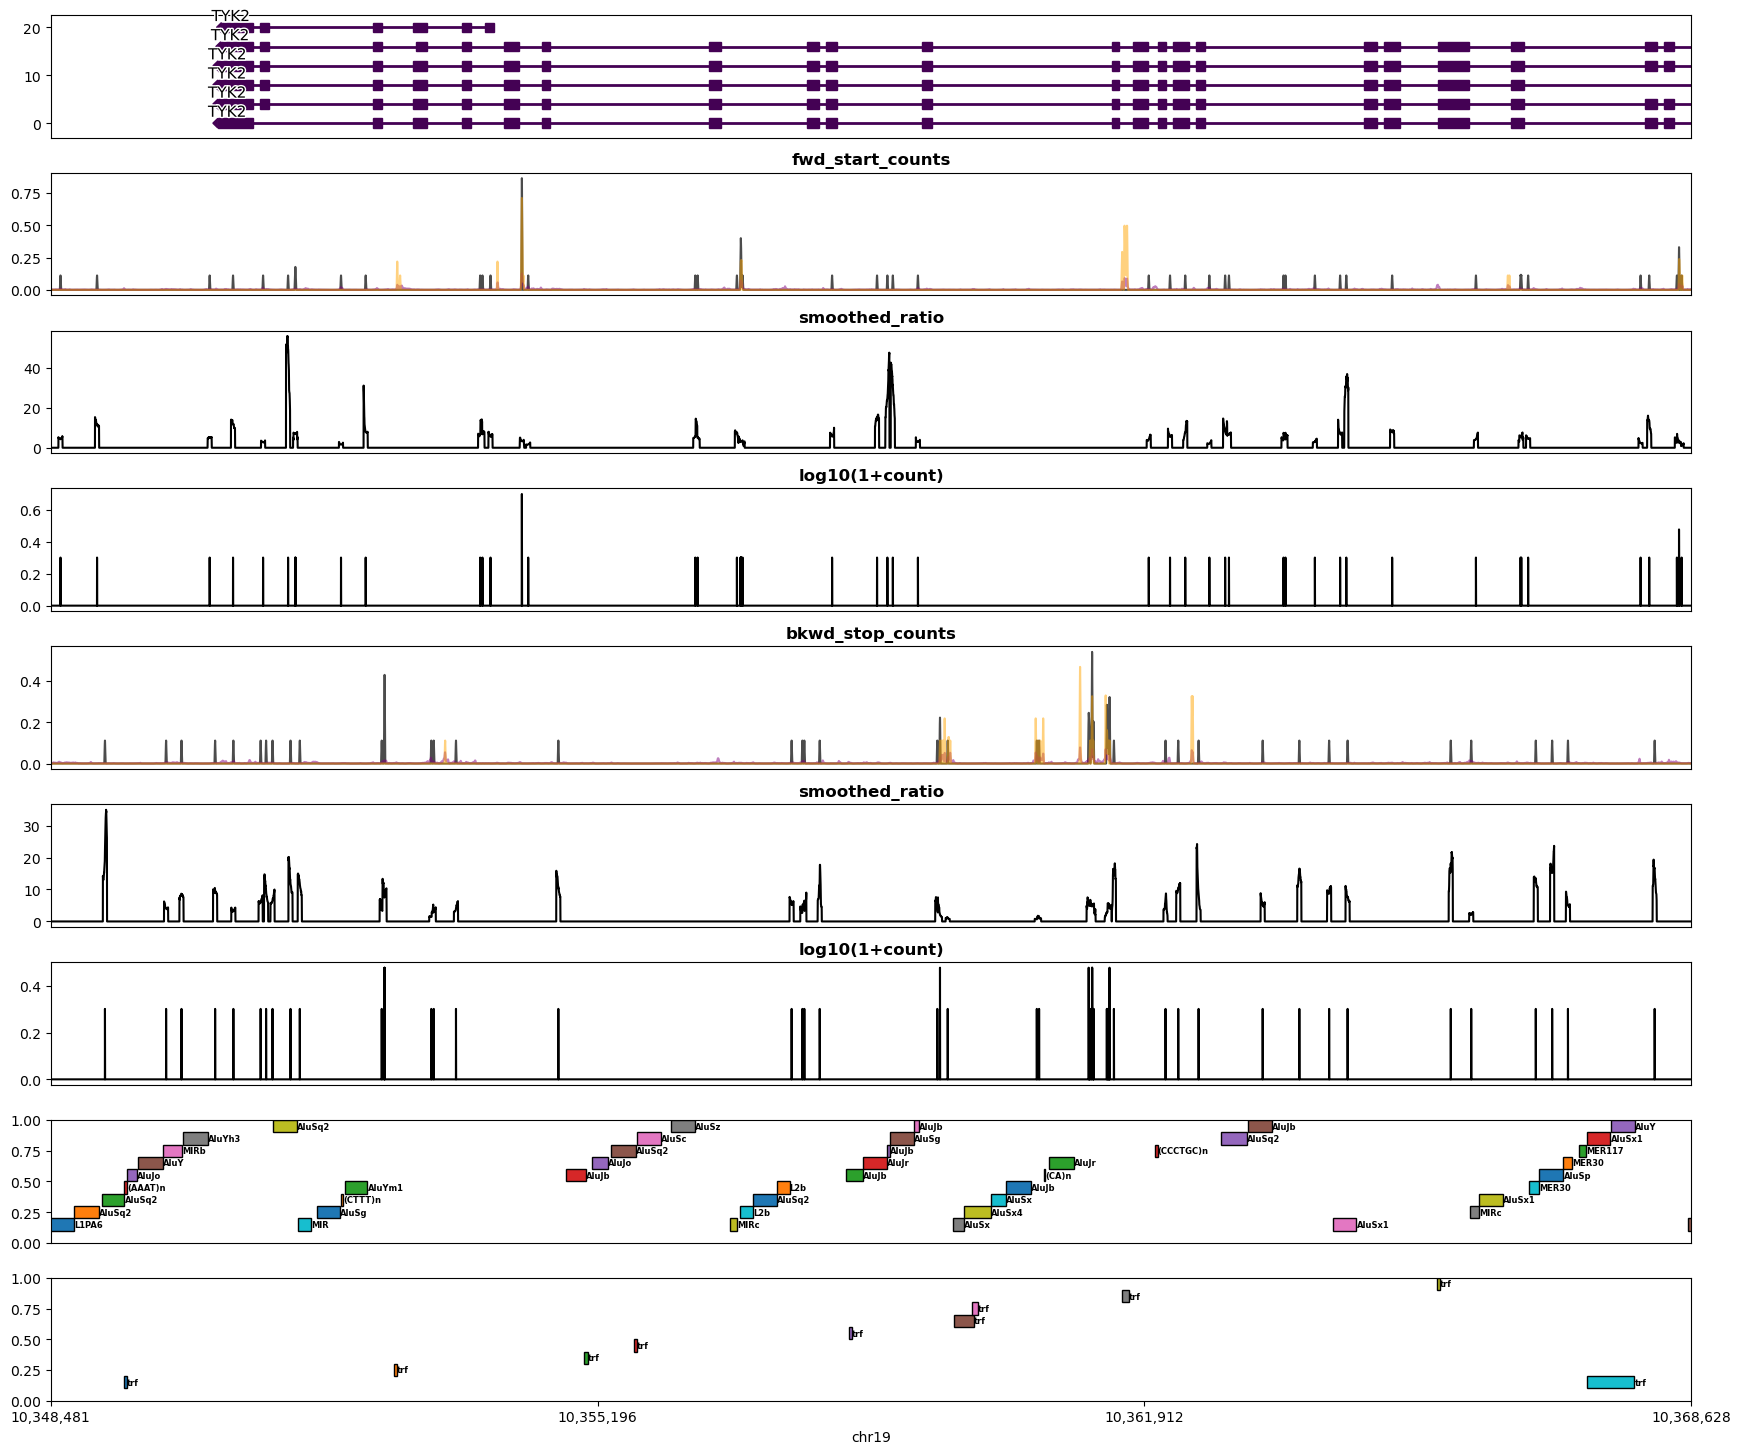

In [199]:
res.make_tracks_for_gene('TYK2', max_scale=False, smooth=50).plot()

In [171]:
test_rdf = test_rdf.drop(columns='blacklist_regions').attach_blacklist_regions("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz")

In [172]:
dists_and_counts = model.predict_from_rdf_and_sdf(test_rdf, (sdf if sample_id == 'merged' else sdf.query("sample_id == @sample_id")))

Predicting dists (1/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 788.52it/s]


Building fragment arrays (2/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 643.40it/s]


Merging fragment arrays (3/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 608.34it/s]


Building observed arrays (4/5)
Building observed arrays (4/5)


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 484.17it/s]

Merging Results (5/5)


In [173]:
stats = dists_and_counts.build_stats_df()

 33%|██████████████████████████████▉                                                                | 121/371 [00:04<00:11, 21.85it/s]WARNING	2024-04-04 20:46:38,054	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/scipy/stats/_discrete_distns.py:368: RuntimeWarning: divide by zero encountered in _nbinom_skewness
  _boost._nbinom_skewness(n, p),

WARNING	2024-04-04 20:46:38,056	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/scipy/stats/_discrete_distns.py:369: RuntimeWarning: divide by zero encountered in _nbinom_kurtosis_excess
  _boost._nbinom_kurtosis_excess(n, p),

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 371/371 [00:13<00:00, 27.19it/s]


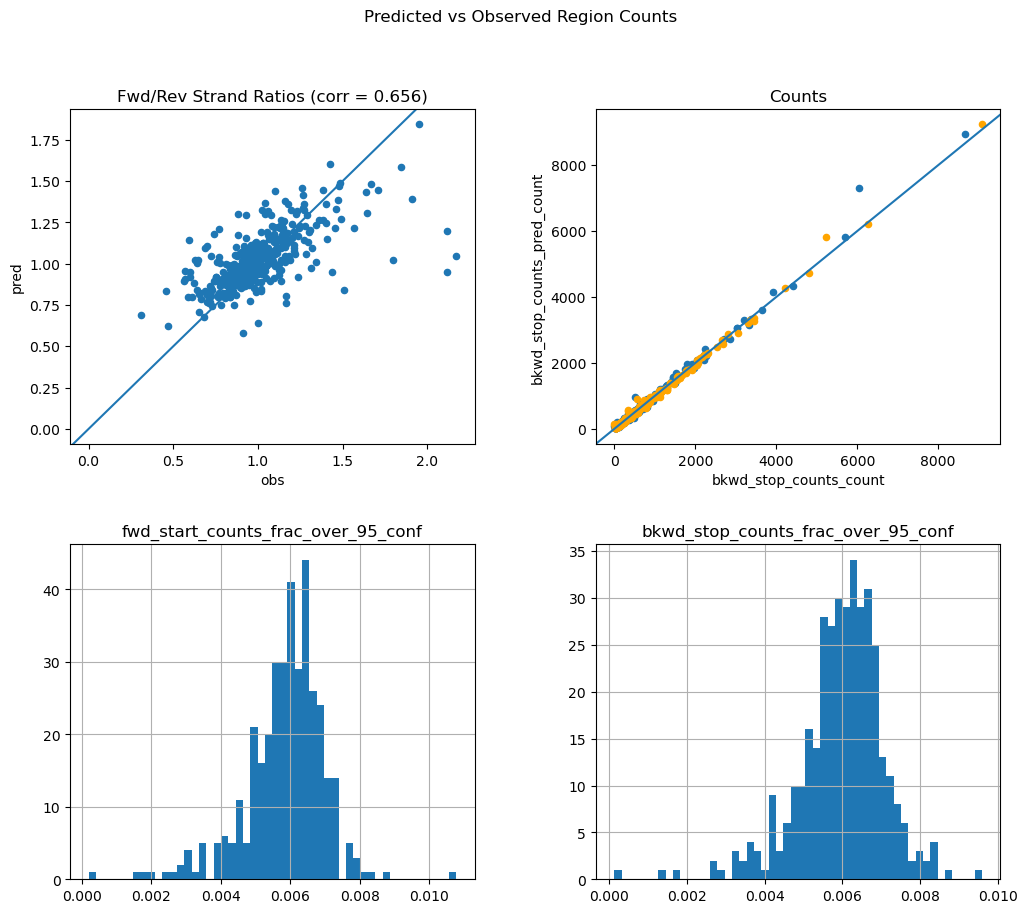

In [174]:
stats.make_qc_plots()

# Negative Binomial Fit 

In [447]:
import statsmodels.formula.api as smf

In [448]:
def initial_dist(counts):
    nbdata = pd.DataFrame({"nbdata": counts})
    nbfit = smf.negativebinomial("nbdata ~ 1", data=nbdata).fit_regularized()
    n, p = convert_params(nbdata.values.mean(), nbfit.params[1])
    return nbinom(n=n, p=p)

In [449]:
def qc_dist(data):
    dist = initial_dist(data)
    print(dist.kwds)
    print(dist.mean(), data.mean())
    print(dist.std(), data.std())
    pred = pd.DataFrame(dist.rvs(len(tmp.iloc[0].fwd_start_counts))).value_counts().rename('pred')
    obs = pd.DataFrame(tmp.iloc[0].fwd_start_counts.astype(int)).value_counts().rename("obs")# , obs=tmp.iloc[0].fwd_start_counts)).value_counts()
    return pd.DataFrame(obs).join(pred).fillna(0).sort_index() # .plot.scatter(x='obs', y='pred')

In [450]:
qc_dist(data = tmp.iloc[10].fwd_start_counts).head(50)

AttributeError: 'Series' object has no attribute 'fwd_start_counts'

In [451]:
dist = tmp.iloc[0].fwd_start_counts_dist
pd.DataFrame(dict(p=dist.kwds['p'], n=dist.kwds['n'])).hist(figsize=(20, 5), bins=50)

AttributeError: 'Series' object has no attribute 'fwd_start_counts_dist'

In [37]:
test_rdf

,gene_name,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction
0,ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon
1,ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon
2,ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon
3,ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon
4,ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon
...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon
367,WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon
368,XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon
369,ZBTB7C,ENSG00000184828,chr18,-,48024624,48043171,0.258426,0.000000e+00,-3.593996,0.023,0.414,0.000000e+00,up_in_colon


In [52]:
test_rdf.index

RangeIndex(start=0, stop=371, step=1)

In [49]:
mask_regions = {gene_name: [] for gene_name in test_rdf.gene_name.tolist()}
for region, record in test_rdf[['contig', 'start', 'stop', 'strand', 'gene_name']].intersect_with_bed("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz").iter_region_row():
    mask_regions[record.gene_name].append(region)

In [51]:
test_rdf.set_index("gene_name").join(pd.Series(mask_regions).rename("repeat_regions"))

,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction,repeat_regions
gene_name,,,,,,,,,,,,,
ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon,"[chr2:168921844-168921879, chr2:168921846-1689..."
ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon,[]
ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon,"[chr16:16149372-16149403, chr16:16155566-16155..."
ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon,"[chr17:7341211-7341387, chr17:7342907-7342932,..."
ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon,"[chr3:123301830-123301869, chr3:123303833-1233..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon,"[chr17:42789665-42789710, chr17:42790006-42790..."
WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon,"[chr1:227918042-227918431, chr1:227918044-2279..."
XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon,"[chr2:31334210-31334236, chr2:31338714-3133874..."


In [138]:
test_rdf.set_index(['gene_name', 'gene_id']).reset_index()

,gene_name,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction
0,ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon
1,ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon
2,ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon
3,ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon
4,ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon
...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon
367,WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon
368,XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon
369,ZBTB7C,ENSG00000184828,chr18,-,48024624,48043171,0.258426,0.000000e+00,-3.593996,0.023,0.414,0.000000e+00,up_in_colon


In [185]:
tmp = test_rdf.set_index('gene_name').intersect_with_rdf(RegionDataFrame.from_bed("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", ref='hg38')[['contig', 'start', 'stop', 'strand']])
blacklist_regions = tmp.reset_index().groupby(tmp.index.names).apply(lambda x: list(x.iter_regions()))

In [200]:
test_rdf.set_index("gene_name").join(blacklist_regions.rename("blacklist_regions")).fillna('')

,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction,blacklist_regions
gene_name,,,,,,,,,,,,,
ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon,"[chr2:-:168918733-169020200, chr2:-:168918733-..."
ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon,
ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon,"[chr16:-:16147517-16225515, chr16:-:16147517-1..."
ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon,"[chr17:+:7334481-7353525, chr17:+:7334481-7353..."
ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon,"[chr3:-:123280248-123370094, chr3:-:123280248-..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon,"[chr17:+:42778562-42799114, chr17:+:42778562-4..."
WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon,"[chr1:-:227916608-227949980, chr1:-:227916608-..."
XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon,"[chr2:-:31332273-31416790, chr2:-:31332273-314..."


In [95]:
bed_columns = ['contig', 'start', 'stop', 'strand']
columns = bed_columns + [c for c in test_rdf.columns if c not in bed_columns]

In [81]:
test_rdf

,gene_name,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction,blacklist_regions
0,ABCB11,ENSG00000073734,chr2,-,168918733,169020200,0.000000,0.000000e+00,-4.517449,0.002,0.089,0.000000e+00,up_in_colon,"[chr2:168921844-168921879, chr2:168921846-1689..."
1,ABCC3,ENSG00000108846,chr17,+,50632729,50637963,4.752529,0.000000e+00,-3.108816,0.067,0.674,0.000000e+00,up_in_colon,
2,ABCC6,ENSG00000091262,chr16,-,16147517,16225515,2.140621,0.000000e+00,-3.247215,0.008,0.192,0.000000e+00,up_in_colon,"[chr16:16149372-16149403, chr16:16155566-16155..."
3,ACAP1,ENSG00000072818,chr17,+,7334481,7353525,90.551726,0.000000e+00,7.517201,0.165,0.003,0.000000e+00,down_in_colon,"[chr17:7341211-7341387, chr17:7342907-7342932,..."
4,ADCY5,ENSG00000173175,chr3,-,123280248,123370094,0.000000,5.274245e-127,-3.863480,0.003,0.038,1.542400e-122,up_in_colon,"[chr3:123301830-123301869, chr3:123303833-1233..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,WNK4,ENSG00000126562,chr17,+,42778562,42799114,0.077122,0.000000e+00,-3.378599,0.007,0.128,0.000000e+00,up_in_colon,"[chr17:42789665-42789710, chr17:42790006-42790..."
367,WNT9A,ENSG00000143816,chr1,-,227916608,227949980,0.326770,1.985908e-53,-3.136547,0.001,0.016,5.807591e-49,up_in_colon,"[chr1:227918042-227918431, chr1:227918044-2279..."
368,XDH,ENSG00000158125,chr2,-,31332273,31416790,0.058328,0.000000e+00,-3.075862,0.020,0.254,0.000000e+00,up_in_colon,"[chr2:31334210-31334236, chr2:31338714-3133874..."
369,ZBTB7C,ENSG00000184828,chr18,-,48024624,48043171,0.258426,0.000000e+00,-3.593996,0.023,0.414,0.000000e+00,up_in_colon,"[chr18:48032104-48032750, chr18:48032422-48032..."
